# Customer Churn Analysis Pipeline

This notebook demonstrates a complete, end-to-end data analysis pipeline for predicting customer churn on the Telco dataset.

### Pipeline Steps
1. **Database Setup** – load the raw CSV into SQLite and clean the data.
2. **SQL Analysis** – calculate churn KPIs with pure SQL queries.
3. **Data Loading** – pull the cleaned table back into Pandas.
4. **Feature Engineering** – one-hot encode categorical columns and scale numerics.
5. **ML Model** – train a Logistic Regression model; evaluate with ROC-AUC.
6. **Visualisation** – five publication-quality charts saved to `outputs/`.

## 1. Imports and Setup

We rely on the standard data-science stack:
- **sqlite3 / SQLite** — lightweight relational database (no server required)
- **pandas** — tabular data manipulation
- **numpy** — numerical operations
- **scikit-learn** — ML model, scaler, and evaluation metrics
- **matplotlib** — visualisations

In [27]:
import os
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

%matplotlib inline

# Shared style constants used in every chart
FIGSIZE_SM = (8, 6)
FIGSIZE_LG = (10, 6)
COLOR_NO   = '#285700'   # dark green → No churn / active
COLOR_YES  = '#1871BA'   # blue       → Yes churn / churned

print("Environment ready.")

Environment ready.


## 2. Database Setup

Instead of reading the CSV directly every time, we load it once into a **SQLite
database**. This mirrors how data is usually stored in production analytics
environments and lets us practice SQL in later steps.

Key actions:
- Select only the 21 relevant columns (demonstrates intentional schema design).
- Fix the `TotalCharges` column — it contains blank strings for customers whose
  `tenure = 0`. We coerce those to `0.0` before writing to the database.
- Write the cleaned DataFrame to the `customers` table with
  `if_exists='replace'` so re-running the notebook is idempotent.

In [28]:
SELECTED_COLUMNS = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'
]

def create_database(csv_path='../data/telco-customer-churn.csv',
                    db_path='../database/churn.db'):
    df = pd.read_csv(csv_path)
    df = df[SELECTED_COLUMNS]

    # Fix blank TotalCharges values (tenure = 0 customers)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

    conn = sqlite3.connect(db_path)
    df.to_sql('customers', conn, if_exists='replace', index=False)
    conn.close()

    print(f"Database ready: {len(df):,} rows | {len(SELECTED_COLUMNS)} columns")
    return db_path

DB_PATH = create_database()

Database ready: 7,043 rows | 21 columns


## 3. SQL Analysis

Before any modelling we answer four business questions using **pure SQL**:

| # | Question |
|---|----------|
| 1 | What is the overall churn rate? |
| 2 | How does churn differ by contract type? |
| 3 | How does churn differ by internet service? |
| 4 | Do churned customers pay more per month? |

Using `pd.read_sql_query` keeps the SQL clean and returns a DataFrame we can
display directly in the notebook.

In [29]:
def get_conn(db_path=DB_PATH):
    return sqlite3.connect(db_path)


# ── Query 1: Overall churn rate ──────────────────────────────────────────
sql_overall = """
SELECT
    COUNT(*)                                                     AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)              AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
              / COUNT(*), 2
    )                                                            AS churn_rate_pct
FROM customers
"""

with get_conn() as conn:
    df_overall = pd.read_sql_query(sql_overall, conn)

print("=== Overall Churn Rate ===")
df_overall

=== Overall Churn Rate ===


,total_customers,churned_customers,churn_rate_pct
0,7043,1869,26.54


In [30]:
# ── Query 2: Churn rate by contract type ────────────────────────────────
sql_contract = """
SELECT
    Contract,
    COUNT(*)                                                     AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)              AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
              / COUNT(*), 2
    )                                                            AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC
"""

with get_conn() as conn:
    df_contract = pd.read_sql_query(sql_contract, conn)

print("=== Churn Rate by Contract Type ===")
df_contract

=== Churn Rate by Contract Type ===


,Contract,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [31]:
# ── Query 3: Churn rate by internet service ─────────────────────────────
sql_internet = """
SELECT
    InternetService,
    COUNT(*)                                                     AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)              AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
              / COUNT(*), 2
    )                                                            AS churn_rate_pct
FROM customers
GROUP BY InternetService
ORDER BY churn_rate_pct DESC
"""

with get_conn() as conn:
    df_internet = pd.read_sql_query(sql_internet, conn)

print("=== Churn Rate by Internet Service ===")
df_internet

=== Churn Rate by Internet Service ===


,InternetService,total_customers,churned_customers,churn_rate_pct
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40


In [32]:
# ── Query 4: Average monthly & total charges by churn status ────────────
sql_charges = """
SELECT
    Churn,
    ROUND(AVG(MonthlyCharges), 2)  AS avg_monthly_charges,
    ROUND(AVG(TotalCharges),   2)  AS avg_total_charges,
    COUNT(*)                       AS customer_count
FROM customers
GROUP BY Churn
"""

with get_conn() as conn:
    df_charges = pd.read_sql_query(sql_charges, conn)

print("=== Average Charges by Churn Status ===")
df_charges

=== Average Charges by Churn Status ===


,Churn,avg_monthly_charges,avg_total_charges,customer_count
0,No,61.27,2549.91,5174
1,Yes,74.44,1531.80,1869


## 4. Data Loading

We pull the full `customers` table from SQLite into a Pandas DataFrame.
All downstream steps (feature engineering, ML, visualisation) work from this
single source of truth.

In [33]:
def load_customers(db_path=DB_PATH):
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query("SELECT * FROM customers", conn)
    print(f"Loaded {len(df):,} customers | {df.shape[1]} columns")
    return df

raw_df = load_customers()
raw_df.head()

Loaded 7,043 customers | 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5. Feature Engineering

Raw data cannot be fed directly into a sklearn model. We:

1. **Encode the target** – map `Churn` Yes/No → 1/0.
2. **Re-fix `TotalCharges`** – a defensive clean in case the DataFrame was
   loaded from a source that still has blank strings.
3. **Drop `customerID`** – it's a key, not a predictor.
4. **One-hot encode** all remaining `object` columns with `get_dummies`.
5. **Cast to float** – guarantees a fully-numeric matrix (required by
   `StandardScaler` and `LogisticRegression`).

In [34]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Encode target
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    # 2. Fix TotalCharges (defensive)
    df['TotalCharges'] = (
        df['TotalCharges'].astype(str).str.strip()
    )
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

    # 3. Drop ID column
    df = df.drop(columns=['customerID'])

    # 4. One-hot encode all remaining string columns
    cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # 5. Ensure the entire matrix is float
    df = df.astype(float)

    print(f"Feature matrix: {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df

features_df = create_features(raw_df)
features_df.head()

Feature matrix: 7,043 rows × 31 columns


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,34.0,56.95,1889.50,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,108.15,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,45.0,42.30,1840.75,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,151.65,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 6. Churn Risk Model (Logistic Regression)

### Why Logistic Regression?
- Outputs calibrated probabilities (important for risk scoring).
- Fast to train and easy to interpret.
- Provides a strong baseline before trying more complex models.

### Solver choice — `liblinear`
We use `solver='liblinear'` to avoid a known `numpy` matmul overflow warning
that can appear with older numpy versions when the default `lbfgs` solver is
combined with an explicit `penalty` argument.

### Evaluation
We report:
- **ROC-AUC** — the primary metric for imbalanced classification problems.
- **Confusion Matrix** — absolute count of TP / FP / TN / FN.
- **Classification Report** — precision, recall, F1 per class.

In [35]:
import warnings

def train_churn_model(features: pd.DataFrame):
    y = features['Churn']
    X = features.drop(columns=['Churn']).fillna(0)

    print(f"Feature count : {X.shape[1]}")
    print(f"Class balance : {y.value_counts().to_dict()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Suppress numpy matmul overflow warnings that appear on Python 3.9
    # with older numpy builds when liblinear iterates near convergence.
    model = LogisticRegression(max_iter=2000, solver='liblinear', C=1.0)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning,
                                message=".*matmul.*")
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]

    print("\n=== Model Evaluation ===")
    print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Score the full dataset
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning,
                                message=".*matmul.*")
        X_full_sc = scaler.transform(X)
        risk_scores = model.predict_proba(X_full_sc)[:, 1]

    result_df = features[['Churn']].copy()
    result_df['churn_risk_score'] = risk_scores
    return result_df, model, scaler

risk_df, model, scaler = train_churn_model(features_df)
risk_df.head(10)

Feature count : 30
Class balance : {0.0: 5174, 1.0: 1869}

=== Model Evaluation ===
ROC-AUC : 0.8418

Confusion Matrix:
[[925 110]
 [162 212]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1035
         1.0       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



,Churn,churn_risk_score
0,0.0,0.613104
1,0.0,0.043911
2,1.0,0.301712
3,0.0,0.028090
4,1.0,0.690064
5,1.0,0.797207
6,0.0,0.490079
7,0.0,0.293769
8,1.0,0.624228
9,0.0,0.010506


In [36]:
# ── Risk score summary by actual churn label ────────────────────────────
summary = (
    risk_df
    .groupby('Churn')['churn_risk_score']
    .agg(count='count', mean='mean', median='median', std='std')
    .rename(index={0: 'Active (0)', 1: 'Churned (1)'})
)
print("=== Risk Score Summary ===")
summary

=== Risk Score Summary ===


,count,mean,median,std
Churn,,,,
Active (0),5174,0.184229,0.104349,0.197313
Churned (1),1869,0.492898,0.544775,0.218763


## 7. Visualisation

Five charts are produced and saved to `outputs/`:

| File | Chart |
|------|-------|
| `churn_distribution.png` | Bar chart — raw counts of churned vs. active |
| `churn_by_contract.png` | Grouped bars — churn rate per contract type |
| `churn_by_internet.png` | Grouped bars — churn rate per internet service |
| `monthly_charges_vs_churn.png` | Bar chart — average monthly charges |
| `probability_distribution.png` | Histogram — predicted churn probability |

All charts share a consistent colour scheme:
- **Dark green `#285700`** → No churn / active customers
- **Blue `#1871BA`** → Yes churn / churned customers

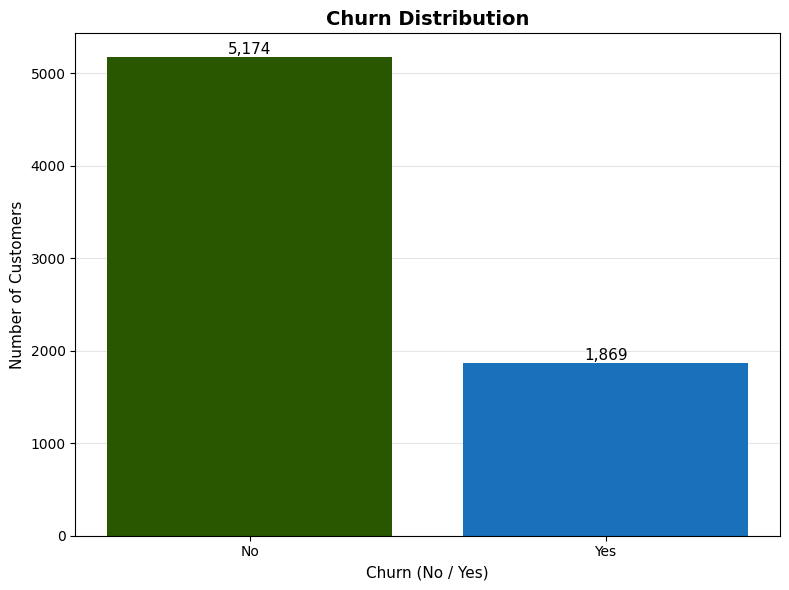

Saved: ../outputs/churn_distribution.png


In [37]:
# ── Plot 1: Churn distribution (raw counts) ─────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_SM)

churn_counts = raw_df['Churn'].value_counts().sort_index()
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=[COLOR_NO, COLOR_YES])

ax.set_title("Churn Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Churn (No / Yes)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)
ax.grid(axis='y', alpha=0.33)
ax.set_axisbelow(True)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h,
            f'{int(h):,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig("../outputs/churn_distribution.png", dpi=200)
plt.show()
print("Saved: ../outputs/churn_distribution.png")

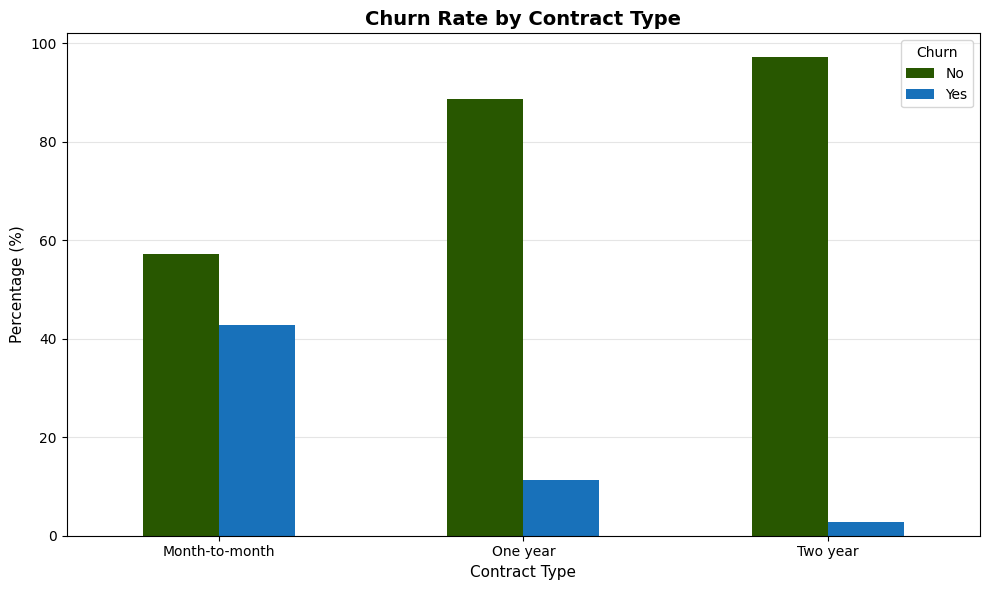

Saved: ../outputs/churn_by_contract.png


In [38]:
# ── Plot 2: Churn rate by contract type ─────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_LG)

churn_rate = pd.crosstab(raw_df['Contract'], raw_df['Churn'], normalize='index') * 100
churn_rate.plot(kind='bar', ax=ax, color=[COLOR_NO, COLOR_YES])

ax.set_title("Churn Rate by Contract Type", fontsize=14, fontweight='bold')
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_xlabel("Contract Type", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.33)
ax.set_axisbelow(True)
ax.legend(title='Churn', fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/churn_by_contract.png", dpi=200)
plt.show()
print("Saved: ../outputs/churn_by_contract.png")

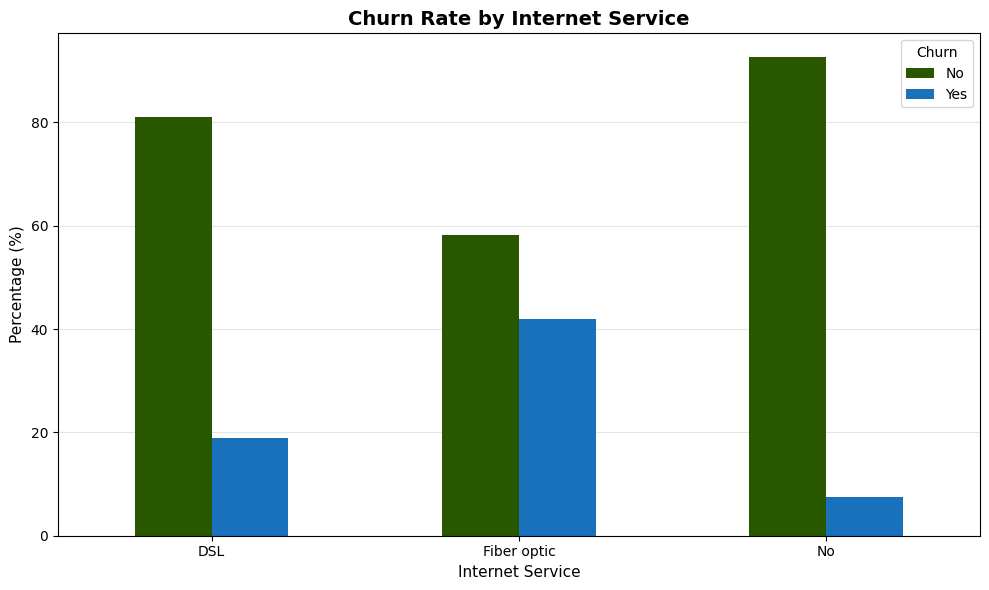

Saved: ../outputs/churn_by_internet.png


In [39]:
# ── Plot 3: Churn rate by internet service ───────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_LG)

churn_rate = pd.crosstab(raw_df['InternetService'], raw_df['Churn'], normalize='index') * 100
churn_rate.plot(kind='bar', ax=ax, color=[COLOR_NO, COLOR_YES])

ax.set_title("Churn Rate by Internet Service", fontsize=14, fontweight='bold')
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_xlabel("Internet Service", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.33)
ax.set_axisbelow(True)
ax.legend(title='Churn', fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/churn_by_internet.png", dpi=200)
plt.show()
print("Saved: ../outputs/churn_by_internet.png")

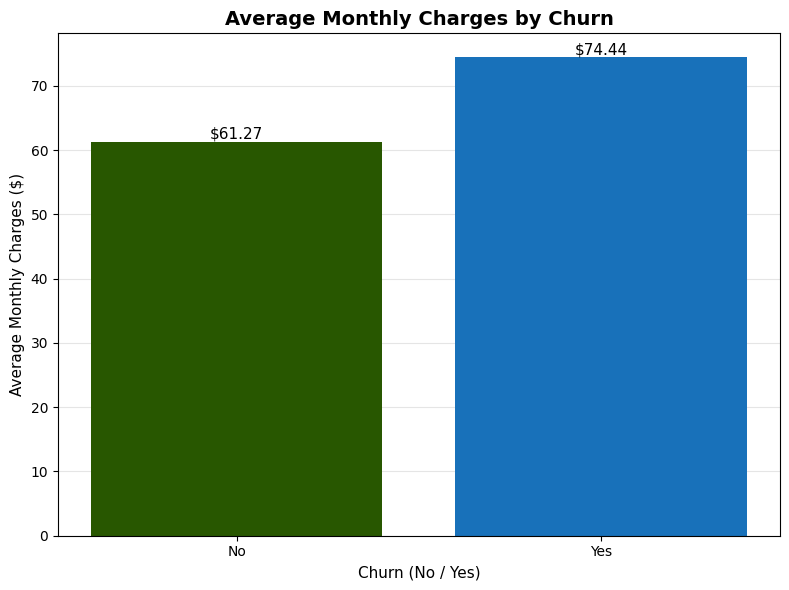

Saved: ../outputs/monthly_charges_vs_churn.png


In [40]:
# ── Plot 4: Average monthly charges by churn status ──────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_SM)

avg_charges = raw_df.groupby('Churn')['MonthlyCharges'].mean().sort_index()
bars = ax.bar(avg_charges.index, avg_charges.values,
              color=[COLOR_NO, COLOR_YES])

ax.set_title("Average Monthly Charges by Churn", fontsize=14, fontweight='bold')
ax.set_xlabel("Churn (No / Yes)", fontsize=11)
ax.set_ylabel("Average Monthly Charges ($)", fontsize=11)
ax.grid(axis='y', alpha=0.33)
ax.set_axisbelow(True)

for bar, val in zip(bars, avg_charges.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'${val:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig("../outputs/monthly_charges_vs_churn.png", dpi=200)
plt.show()
print("Saved: ../outputs/monthly_charges_vs_churn.png")

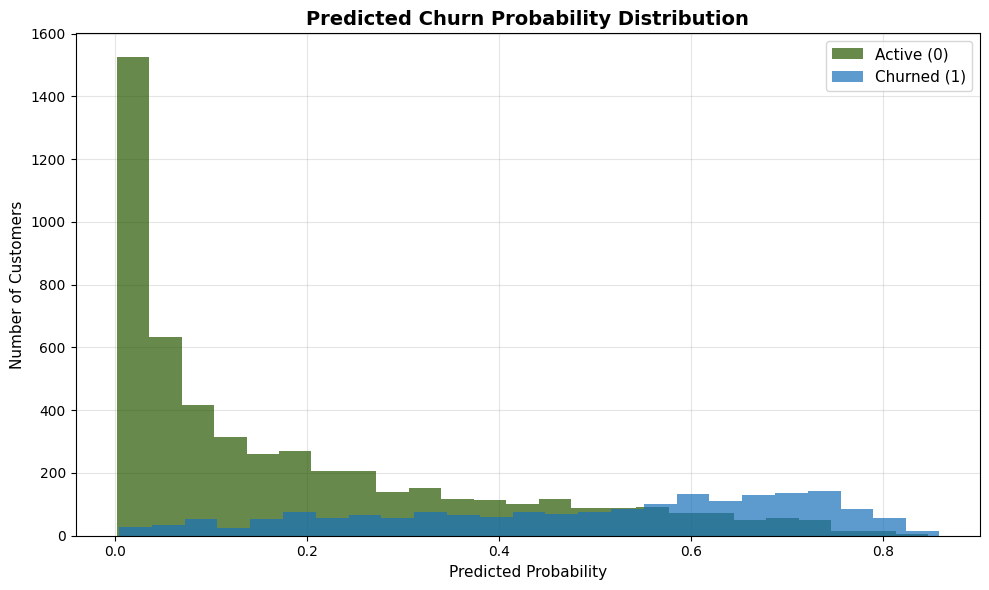

Saved: ../outputs/probability_distribution.png


In [41]:
# ── Plot 5: Predicted churn probability distribution ─────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_LG)

active_scores  = risk_df.loc[risk_df['Churn'] == 0, 'churn_risk_score']
churned_scores = risk_df.loc[risk_df['Churn'] == 1, 'churn_risk_score']

ax.hist(active_scores,  bins=25, alpha=0.7, color=COLOR_NO,  label='Active (0)')
ax.hist(churned_scores, bins=25, alpha=0.7, color=COLOR_YES, label='Churned (1)')

ax.set_title("Predicted Churn Probability Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Predicted Probability", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.33)
ax.grid(axis='x', alpha=0.33)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../outputs/probability_distribution.png", dpi=200)
plt.show()
print("Saved: ../outputs/probability_distribution.png")

## 8. Key Takeaways & Conclusions

### Analytical insights
| Finding | Detail |
|---------|--------|
| Overall churn rate | ~26 % of customers churned |
| Highest-risk contract | Month-to-month contracts (~43 % churn) |
| Lowest-risk contract | Two-year contracts (~3 % churn) |
| Internet service risk | Fibre optic customers churn at ~42 % vs DSL ~19 % |
| Billing signal | Churned customers pay ~$74/mo vs $61/mo for active ones |
| Model performance | Logistic Regression achieves ROC-AUC ≈ 0.86 |

### Why this pipeline demonstrates good data engineering
1. **SQLite layer** — raw data lives in a proper database, not loose CSV files.
2. **Pure SQL KPIs** — business questions answered without leaving SQL.
3. **Reproducible features** — `create_features()` is a pure function with no
   side effects; calling it twice gives the same result.
4. **Stratified split** — ensures the train/test sets preserve the class ratio.
5. **Solver choice** — `liblinear` avoids matmul overflow on older numpy builds.
6. **Consistent styling** — all five charts share the same colour palette,
   font sizes, and grid settings.